In [1]:
from sklearn.datasets import make_classification
import numpy as np

x, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=10
)

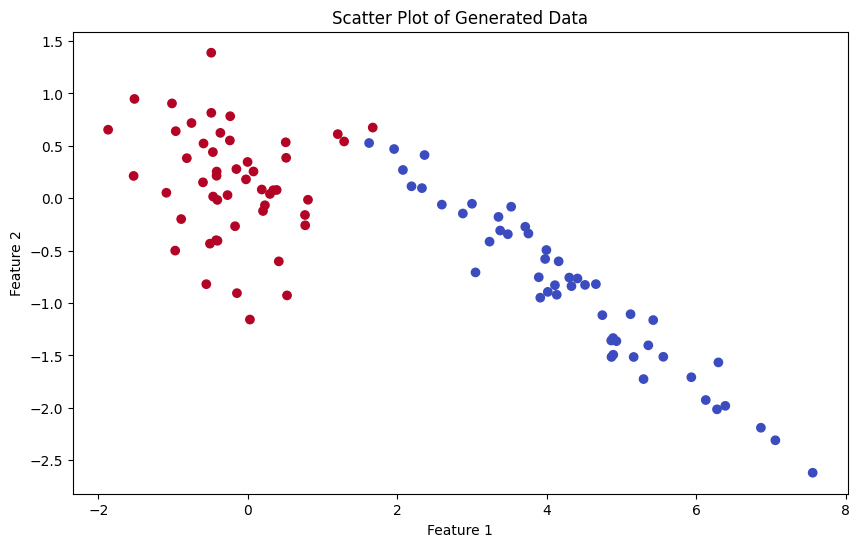

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='coolwarm')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot of Generated Data')
plt.show()

In [3]:
def perceptron(x,y):
    x=np.insert(x,0,1,axis=1)
    weights=np.ones(x.shape[1])
    lr=0.1
    epoch=1000
    for z in range(epoch):
        j=np.random.randint(0,100)
        y_hat=step(np.dot(x[j],weights))
        weights+=lr*(y[j]-y_hat)*x[j]
    return weights[0],weights[1:]

In [4]:
def step(z):
    return 1 if z>=0 else 0


In [5]:
intercept_,coef_=perceptron(x,y)
print("intercept:",intercept_)
print("coef:",coef_)

intercept: 1.0
coef: [-0.87144253  0.50116012]


In [6]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])


In [7]:
x_input=np.linspace(-3,3,100)
y_input=m*x_input+b

(-3.0, 2.0)

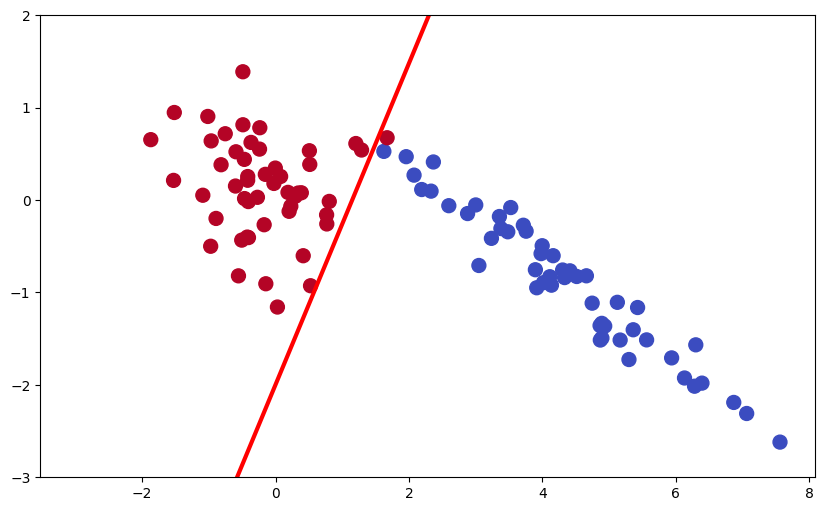

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(x_input,y_input,color='red',linewidth=3,label='Decision Boundary')
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='coolwarm',s=100)
plt.ylim(-3,2)


In [9]:
def perceptron(x,y):
    m=[]
    b=[]
    x=np.insert(x,0,1,axis=1)
    weights=np.ones(x.shape[1])
    lr=0.1
    epoch=1000
    for z in range(epoch):
        j=np.random.randint(0,100)
        y_hat=step(np.dot(x[j],weights))
        weights+=lr*(y[j]-y_hat)*x[j]
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
    return m,b


In [10]:
m,b=perceptron(x,y)

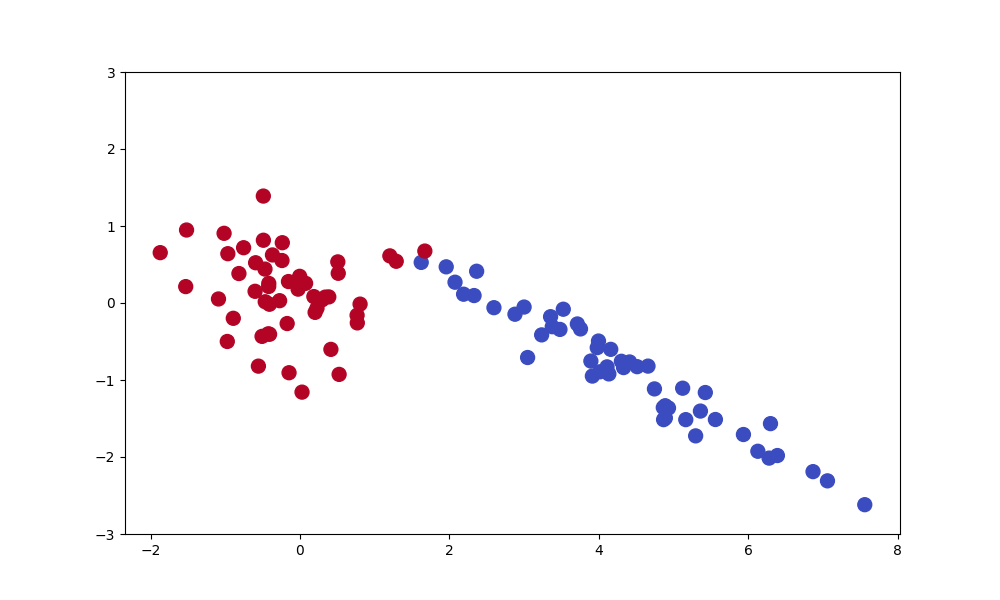

In [13]:
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(x[:,0], x[:,1], c=y, cmap='coolwarm', s=100)
line,= ax.plot([], [], color='red', linewidth=3)
x_input = np.linspace(-3, 3, 100)
plt.ylim(-3, 3)

def animate(i):
    line.set_data(x_input, m[i] * x_input + b[i])
    ax.set_title(f"Epoch {i+1}")
    return line,

anim = FuncAnimation(
    fig,
    animate,
    frames=len(m),
    interval=200,
    repeat=False   )
plt.show()


In [15]:
nums=[5,3,7]
res=[]
def solve(index,total):
    if index>=len(nums):
        res.append(total)
        return
    summ=total+nums[index]
    solve(index+1,summ)
    summ=total
    solve(index+1,summ)
solve(0,0)
print(res)

[15, 8, 12, 5, 10, 3, 7, 0]
